# FINANCE 361 Lecture 2 (Topic 4) Notebook

This notebook is an applied companion to **Lecture 2 — Topic 4: Expected Utility Theory and Mean–Variance Portfolio Choice**.

Focus:
- Markowitz (tangency / maximum Sharpe) portfolio weights
- Ridge / Tikhonov-regularised portfolio weights

Dataset source: `dataset.csv` (monthly stock returns, 1998-01 to 2024-12).


## How to Use This Notebook

1. Run cells from top to bottom (`Shift + Enter`).
2. Read the markdown before each code block (the goal is *interpretation*, not just output).
3. If the Fama–French download step fails (no internet), set `USE_FAMA_FRENCH_RF = False` to continue with $r_f=0$.


In [1]:
from __future__ import annotations

from pathlib import Path

import io
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

try:
    import requests  # used only if we download Fama-French data
except Exception:
    requests = None

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


## Data Loading and Basic Checks

We start from the stock-return dataset and keep basic diagnostics visible.


In [2]:
data_path = 'dataset.csv'
df_ret = pd.read_csv(data_path, parse_dates=['date'])
df_ret = df_ret.sort_values('date').set_index('date')

print(f'Using data file: {data_path}')
print(f'Rows (months): {df_ret.shape[0]}, Columns (assets): {df_ret.shape[1]}')
df_ret.head()


Using data file: dataset.csv
Rows (months): 324, Columns (assets): 75


,AAPL,ABT,ADBE,AIG,AMD,AMGN,AMZN,AXP,BA,BAC,...,TGT,TMO,TXN,UNH,UNP,USB,VZ,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
1998-01-01,0.395228,0.081107,-0.066229,0.015086,0.137324,-0.076212,-0.020750,-0.059886,-0.026820,-0.009313,...,0.065741,-0.113636,0.216196,0.031446,-0.035365,-0.036911,0.017170,-0.059678,0.011196,-0.030643
1998-02-01,0.290109,0.060603,0.147727,0.089518,0.164087,0.062500,0.305085,0.076176,0.139108,0.144050,...,0.074717,0.051282,0.061784,0.184146,-0.147917,0.069239,-0.022048,0.125214,0.163265,0.074816
1998-03-01,0.164020,0.006684,0.022631,0.047842,0.236702,0.145882,0.110796,0.019431,-0.036396,0.064781,...,0.140974,-0.015244,-0.066810,0.066942,0.101466,0.004246,0.139276,0.018091,0.097165,0.067853
1998-04-01,-0.004545,-0.029046,0.107884,0.045308,-0.045161,-0.020534,0.072709,0.113002,-0.039568,0.047763,...,-0.007812,-0.013932,0.184758,0.085436,-0.023890,0.072810,-0.084964,-0.040602,-0.003409,0.080406
1998-05-01,-0.027400,0.018531,-0.201929,-0.058907,-0.295045,0.014675,-0.039509,0.006443,-0.046193,-0.006579,...,0.062277,-0.117739,-0.196727,-0.088968,-0.116438,-0.034619,-0.013180,-0.025079,0.090235,-0.035073


In [3]:
df_ret.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 324 entries, 1998-01-01 to 2024-12-01
Data columns (total 75 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    324 non-null    float64
 1   ABT     324 non-null    float64
 2   ADBE    324 non-null    float64
 3   AIG     324 non-null    float64
 4   AMD     324 non-null    float64
 5   AMGN    324 non-null    float64
 6   AMZN    324 non-null    float64
 7   AXP     324 non-null    float64
 8   BA      324 non-null    float64
 9   BAC     324 non-null    float64
 10  BK      324 non-null    float64
 11  BMY     324 non-null    float64
 12  BRK-B   324 non-null    float64
 13  C       324 non-null    float64
 14  CAT     324 non-null    float64
 15  CL      324 non-null    float64
 16  CMCSA   324 non-null    float64
 17  COF     324 non-null    float64
 18  COP     324 non-null    float64
 19  COST    324 non-null    float64
 20  CSCO    324 non-null    float64
 21  CVS     324 non-null    float64

In [4]:
# Full descriptive statistics for all available assets.
df_ret.describe().T


,count,mean,std,min,25%,50%,75%,max
AAPL,324.000000,0.031381,0.115287,-0.577437,-0.033722,0.033053,0.099804,0.453782
ABT,324.000000,0.010066,0.057651,-0.207369,-0.026212,0.012491,0.047652,0.167026
ADBE,324.000000,0.020393,0.116742,-0.334615,-0.045436,0.029320,0.081383,0.852440
AIG,324.000000,0.009463,0.194980,-0.845044,-0.044087,0.008069,0.050339,2.449771
AMD,324.000000,0.024974,0.187286,-0.410489,-0.088293,0.007537,0.148551,0.780996
...,...,...,...,...,...,...,...,...
USB,324.000000,0.008860,0.081197,-0.396053,-0.031278,0.009660,0.048593,0.287719
VZ,324.000000,0.005763,0.064446,-0.204781,-0.032732,0.001749,0.045248,0.376093
WFC,324.000000,0.009878,0.085143,-0.359789,-0.028550,0.010639,0.044047,0.405196
WMT,324.000000,0.011311,0.060263,-0.207365,-0.023433,0.011023,0.044410,0.265881


## Risk-Free Rate ($r_f$) via Fama–French

The tangency (maximum Sharpe) portfolio uses **expected excess returns** $\mu^e = \mu - r_f\mathbf{1}$.

We will pull monthly `RF` from the Fama–French 5-factor dataset and merge it by date.
`https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/`

If you are offline, switch `USE_FAMA_FRENCH_RF` to `False` and the notebook will proceed with $r_f=0$ (so $\mu^e=\mu$).


In [5]:
USE_FAMA_FRENCH_RF = True

# Ken French data library (Dartmouth) — loading the data directly from the URL.
FF_ZIP_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'


In [6]:
if USE_FAMA_FRENCH_RF:
    try:
        # Download the ZIP file
        response = requests.get(FF_ZIP_URL)
        z = zipfile.ZipFile(io.BytesIO(response.content))
        # Extract the CSV file (assuming it is the first file in the ZIP)
        csv_filename = z.namelist()[0]
        with z.open(csv_filename) as file:
            df_factors = pd.read_csv(file, skiprows=3, index_col=0)

        # Keep monthly data only (cut before the annual section begins).
        df_factors = df_factors.loc[:'202412']

        df_factors.index = pd.to_datetime(df_factors.index, format='%Y%m')
        df_factors = df_factors.apply(pd.to_numeric) / 100.0  # convert % to decimal
        df_factors = df_factors.rename_axis('date').reset_index()

        # Merge with returns (inner join: keeps only common dates).
        df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()

    except Exception as e:
        print(f'Download failed ({type(e).__name__}). Proceeding with r_f = 0.')
        USE_FAMA_FRENCH_RF = False

else:
    # Offline/error fallback: proceed with r_f = 0 and no factor columns.
    df = df_ret.copy()

print(f'Merged dataset rows: {df.shape[0]} (324 months from 1998-01 to 2024-12)')
df.head()


Merged dataset rows: 324 (324 months from 1998-01 to 2024-12)


,AAPL,ABT,ADBE,AIG,AMD,AMGN,AMZN,AXP,BA,BAC,...,VZ,WFC,WMT,XOM,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,,,,,,,,,,,,,,,
1998-01-01,0.395228,0.081107,-0.066229,0.015086,0.137324,-0.076212,-0.020750,-0.059886,-0.026820,-0.009313,...,0.017170,-0.059678,0.011196,-0.030643,0.001400,-0.012800,-0.016800,0.009100,-0.006200,0.004300
1998-02-01,0.290109,0.060603,0.147727,0.089518,0.164087,0.062500,0.305085,0.076176,0.139108,0.144050,...,-0.022048,0.125214,0.163265,0.074816,0.070400,0.000500,-0.009300,-0.003700,-0.025800,0.003900
1998-03-01,0.164020,0.006684,0.022631,0.047842,0.236702,0.145882,0.110796,0.019431,-0.036396,0.064781,...,0.139276,0.018091,0.097165,0.067853,0.047600,-0.007300,0.013800,-0.005500,-0.002300,0.003900
1998-04-01,-0.004545,-0.029046,0.107884,0.045308,-0.045161,-0.020534,0.072709,0.113002,-0.039568,0.047763,...,-0.084964,-0.040602,-0.003409,0.080406,0.007400,0.000100,0.010300,-0.016800,-0.003600,0.004300
1998-05-01,-0.027400,0.018531,-0.201929,-0.058907,-0.295045,0.014675,-0.039509,0.006443,-0.046193,-0.006579,...,-0.013180,-0.025079,0.090235,-0.035073,-0.030500,-0.030000,0.034100,0.010300,0.024700,0.004000


## Stock Selection

Select a small set of assets (e.g., 7 stocks) for the Markowitz and Tikhonov calculations.


In [7]:
# Available tickers in the dataset.
available_tickers = df_ret.columns.tolist()
available_tickers[:15], len(available_tickers)


(['AAPL',
  'ABT',
  'ADBE',
  'AIG',
  'AMD',
  'AMGN',
  'AMZN',
  'AXP',
  'BA',
  'BAC',
  'BK',
  'BMY',
  'BRK-B',
  'C',
  'CAT'],
 75)

In [8]:
my_stock_selection = ['ABT', 'WMT', 'LLY', 'SO', 'DHR', 'AAPL', 'LOW']

missing = sorted(set(my_stock_selection) - set(df.columns))
if missing:
    raise ValueError(f'Tickers not found in data: {missing}')

stocks = df[my_stock_selection].copy()
stocks.describe().T


,count,mean,std,min,25%,50%,75%,max
ABT,324.000000,0.010066,0.057651,-0.207369,-0.026212,0.012491,0.047652,0.167026
WMT,324.000000,0.011311,0.060263,-0.207365,-0.023433,0.011023,0.044410,0.265881
LLY,324.000000,0.012490,0.075554,-0.297081,-0.029869,0.008202,0.050757,0.316418
SO,324.000000,0.010349,0.052410,-0.142613,-0.019678,0.012634,0.042135,0.225703
DHR,324.000000,0.015953,0.075149,-0.172413,-0.027036,0.014947,0.050743,0.554943
AAPL,324.000000,0.031381,0.115287,-0.577437,-0.033722,0.033053,0.099804,0.453782
LOW,324.000000,0.016207,0.085348,-0.253138,-0.038968,0.009007,0.072793,0.329506


## Correlations (Diversification Intuition)

Correlation is not the optimisation input (that is $\Sigma$), but it is a quick way to see whether diversification is likely to help.


In [9]:
corr = stocks.corr()
corr


,ABT,WMT,LLY,SO,DHR,AAPL,LOW
ABT,1.000000,0.162828,0.373611,0.180797,0.311135,0.099264,0.193493
WMT,0.162828,1.000000,0.156619,0.071760,0.209202,0.114454,0.364130
LLY,0.373611,0.156619,1.000000,0.042914,0.119369,-0.046310,0.031227
SO,0.180797,0.071760,0.042914,1.000000,0.103321,0.001209,-0.011166
DHR,0.311135,0.209202,0.119369,0.103321,1.000000,0.274718,0.324017
AAPL,0.099264,0.114454,-0.046310,0.001209,0.274718,1.000000,0.259721
LOW,0.193493,0.364130,0.031227,-0.011166,0.324017,0.259721,1.000000


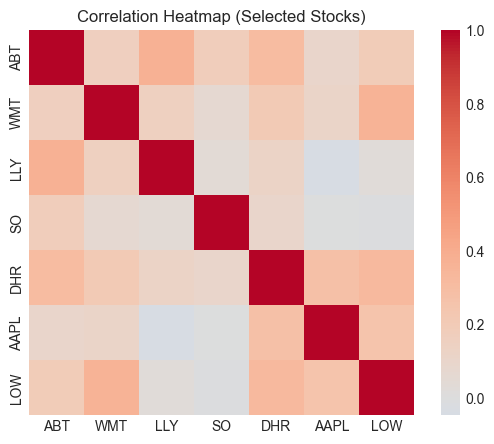

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap (Selected Stocks)')
plt.show()


## Portfolio Inputs: $\mu$ and $\Sigma$

For portfolio weights $w$ and return vector $r$:
- Expected return: $\mathbb{E}[r_p] = w^\top\mu$
- Variance: $\mathrm{Var}(r_p) = w^\top\Sigma w$

We estimate $\Sigma$ from historical data. Note: subtracting a constant (like $r_f$) does **not** change covariances, so we can compute $\Sigma$ using raw returns.


In [11]:
# Population-style covariance estimate from the lecture notes: Sigma_hat = (1/T) R^T R
R = stocks.subtract(stocks.mean())
T = len(stocks)
Sigma_pop = (R.T @ R) / T

# Unbiased sample estimate divides by (T-1) instead.
Sigma_samp = (R.T @ R) / (T - 1)

Sigma = Sigma_samp  # use the unbiased sample estimate
Sigma


,ABT,WMT,LLY,SO,DHR,AAPL,LOW
ABT,0.003324,0.000566,0.001627,0.000546,0.001348,0.000660,0.000952
WMT,0.000566,0.003632,0.000713,0.000227,0.000947,0.000795,0.001873
LLY,0.001627,0.000713,0.005708,0.000170,0.000678,-0.000403,0.000201
SO,0.000546,0.000227,0.000170,0.002747,0.000407,0.000007,-0.000050
DHR,0.001348,0.000947,0.000678,0.000407,0.005647,0.002380,0.002078
AAPL,0.000660,0.000795,-0.000403,0.000007,0.002380,0.013291,0.002556
LOW,0.000952,0.001873,0.000201,-0.000050,0.002078,0.002556,0.007284


## Excess Returns

Define excess returns $r^e_t = r_t - r_{f,t}$. The tangency portfolio uses the vector of expected excess returns:
$$\mu^e = \mathbb{E}[r^e].$$


In [12]:
if USE_FAMA_FRENCH_RF and 'RF' in df.columns:
    rf = df['RF']
else:
    rf = pd.Series(0.0, index=stocks.index, name='RF')

stocks_excess = stocks.subtract(rf, axis=0)
mu_e = stocks_excess.mean()
mu_e


ABT    0.008415
WMT    0.009660
LLY    0.010840
SO     0.008698
DHR    0.014303
AAPL   0.029730
LOW    0.014556
dtype: float64

## Markowitz Tangency (Maximum Sharpe) Portfolio

With weights summing to one ($\mathbf{1}^\top w = 1$), the tangency portfolio weights are:
$$w^\star = \frac{\Sigma^{-1}\mu^e}{\mathbf{1}^\top\Sigma^{-1}\mu^e}.$$


In [13]:
def tangency_weights(Sigma: np.ndarray, mu_excess: np.ndarray) -> np.ndarray:
    mu_excess = np.asarray(mu_excess, dtype=float).reshape(-1)
    ones = np.ones_like(mu_excess)

    z = np.linalg.pinv(Sigma) @ mu_excess

    denom = ones @ z
    if np.isclose(denom, 0.0):
        raise ValueError('Normalisation failed: 1^T Σ^{+} μ^e is ~0.')

    return z / denom

In [14]:
w_mkv = tangency_weights(Sigma.values if hasattr(Sigma, 'values') else Sigma, mu_e.values)
w_mkv = pd.Series(w_mkv, index=my_stock_selection, name='Markowitz')
w_mkv, w_mkv.sum()


(ABT    0.014959
 WMT    0.120392
 LLY    0.178465
 SO     0.306823
 DHR    0.089162
 AAPL   0.207809
 LOW    0.082390
 Name: Markowitz, dtype: float64,
 np.float64(1.0))

In [15]:
mu_p_excess = float(w_mkv.values @ mu_e.values)
sigma_p = float(np.sqrt(w_mkv.values @ Sigma.values @ w_mkv.values))
sharpe = mu_p_excess / sigma_p

summary = pd.DataFrame({
    'Expected excess return (monthly)': [mu_p_excess],
    'Volatility (monthly)': [sigma_p],
    'Sharpe (monthly)': [sharpe],
}, index=['Markowitz'])
summary


,Expected excess return (monthly),Volatility (monthly),Sharpe (monthly)
Markowitz,0.014545,0.039694,0.366421


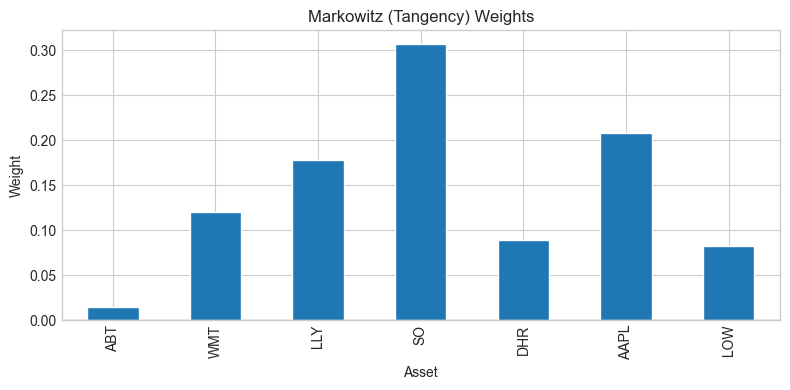

In [16]:
ax = w_mkv.plot(kind='bar', figsize=(8, 4), title='Markowitz (Tangency) Weights')
ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Ridge / Tikhonov-Regularised Weights

Classical Markowitz weights can become extreme when $\mu^e$ and $\Sigma$ are estimated with noise.

The lecture notes present a **Tikhonov (ridge) regularisation** via a convenient regression form. Let $X$ be the $T \times N$ matrix of historical **excess** returns. Ridge regression of a constant on those returns,
$$\mathbf{1}_T = X\theta + u \quad \text{with penalty } \lambda\,\theta'\theta,$$
has the closed-form solution
$$\hat\theta = (X'X+\lambda I)^{-1}X'\mathbf{1}_T.$$
The portfolio weights are obtained by normalising:
$$w_{\text{Tik}} = \frac{\hat\theta}{\mathbf{1}'\hat\theta}.$$

Key properties:
- $\lambda = 0$: reduces to the OLS direction (no shrinkage).
- Larger $\lambda$: inflates the diagonal of the second-moment matrix $X'X$, shrinking weights toward more equal magnitudes and improving robustness to estimation error.

In [17]:
lambda_parameter = 0.6  # try 0, 0.1, 0.3, 0.6, 1.0, ...


In [18]:
# Regression-style Tikhonov form from the lecture notes (Section 6.2).
# X has shape (T, N): each row is a month, each column is an excess return.
# Regress a vector of ones on X with L2 penalty lambda.
X = stocks_excess.values
y = np.ones(X.shape[0])
I = np.eye(len(my_stock_selection))

Theta = np.linalg.pinv((X.T @ X) + (lambda_parameter * I)) @ (X.T @ y)
w_tik = Theta / Theta.sum()
w_tik = pd.Series(w_tik, index=my_stock_selection, name=f'Tikhonov(λ={lambda_parameter})')
w_tik, w_tik.sum()

(ABT    0.056859
 WMT    0.119499
 LLY    0.165462
 SO     0.229133
 DHR    0.105796
 AAPL   0.228983
 LOW    0.094269
 Name: Tikhonov(λ=0.6), dtype: float64,
 np.float64(0.9999999999999999))

In [19]:
# Compare Markowitz and Tikhonov weights side-by-side.
w_compare = pd.concat([w_mkv, w_tik], axis=1)
w_compare

,Markowitz,Tikhonov(λ=0.6)
ABT,0.014959,0.056859
WMT,0.120392,0.119499
LLY,0.178465,0.165462
SO,0.306823,0.229133
DHR,0.089162,0.105796
AAPL,0.207809,0.228983
LOW,0.082390,0.094269


In [20]:
def portfolio_summary(weights: pd.Series, mu_excess: pd.Series, Sigma: pd.DataFrame) -> pd.Series:
    w = weights.values.astype(float)
    mu_p = float(w @ mu_excess.values)
    sig = float(np.sqrt(w @ Sigma.values @ w))
    return pd.Series({
        'E[excess] (monthly)': mu_p,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mu_p / sig,
    }, name=weights.name)

perf = pd.concat([
    portfolio_summary(w_mkv, mu_e, Sigma),
    portfolio_summary(w_tik, mu_e, Sigma),
], axis=1).T
perf

,E[excess] (monthly),Vol (monthly),Sharpe (monthly)
Markowitz,0.014545,0.039694,0.366421
Tikhonov(λ=0.6),0.015112,0.041619,0.363115


In [21]:
# X, y, I defined in the Tikhonov cell above — run cells in order.
lambdas = np.logspace(start=-4, stop=0, num=10, base=10.0)
W = {}
for lam in lambdas:
    Theta_lam = np.linalg.pinv((X.T @ X) + lam * I) @ (X.T @ y)
    W[lam] = Theta_lam / Theta_lam.sum()

df_path = pd.DataFrame(W, index=my_stock_selection).T
df_path.index.name = 'lambda'
df_path

,ABT,WMT,LLY,SO,DHR,AAPL,LOW
lambda,,,,,,,
0.000100,0.015568,0.123454,0.177555,0.307282,0.087308,0.207849,0.080984
0.000278,0.015592,0.123454,0.177549,0.307244,0.087315,0.207858,0.080988
0.000774,0.015659,0.123452,0.177533,0.307138,0.087336,0.207882,0.081000
0.002154,0.015843,0.123449,0.177489,0.306845,0.087394,0.207948,0.081031
0.005995,0.016354,0.123441,0.177367,0.306034,0.087555,0.208132,0.081117
0.016681,0.017742,0.123413,0.177033,0.303813,0.088000,0.208639,0.081360
0.046416,0.021379,0.123312,0.176149,0.297890,0.089212,0.210014,0.082044
0.129155,0.030017,0.122896,0.173974,0.283167,0.092381,0.213583,0.083982
0.359381,0.046426,0.121274,0.169270,0.251999,0.099796,0.221962,0.089273


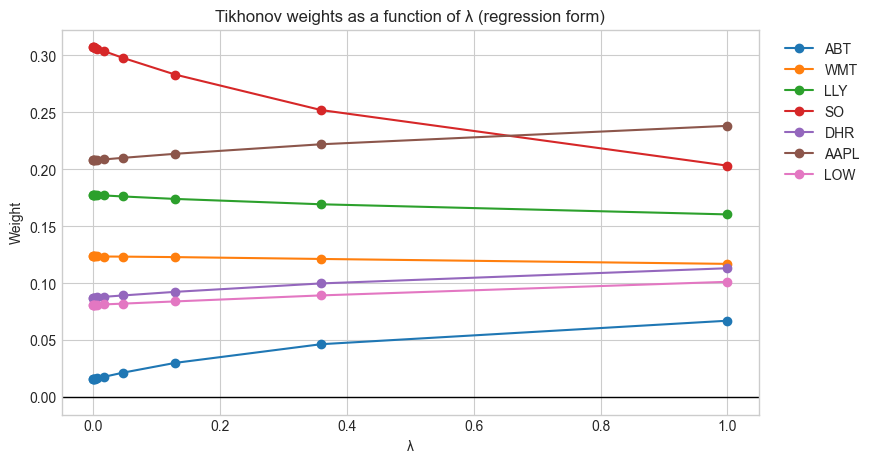

In [22]:
ax = df_path.plot(figsize=(9, 5), marker='o')
ax.set_title('Tikhonov weights as a function of λ (regression form)')
ax.set_xlabel('λ')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

---

## Appendix: Global Minimum-Variance (GMV) Portfolio

The GMV portfolio minimises variance with no reference to expected returns:
$$\min_w \; w'\Sigma w \quad \text{s.t.} \quad w'\mathbf{1} = 1.$$

The closed-form solution (lecture notes, Proposition 2) is:
$$w^\star_{\min} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}'\Sigma^{-1}\mathbf{1}}.$$

Because expected returns are not used, GMV weights depend only on second moments (covariances). This makes GMV more stable than the tangency portfolio but ignores return information entirely.

In [23]:
def gmv_weights(Sigma: np.ndarray) -> np.ndarray:
    ones = np.ones(Sigma.shape[0])
    z = np.linalg.pinv(Sigma) @ ones  # Sigma^{+} * 1 (pseudo-inverse)
    return z / (ones @ z)             # normalise: 1' Sigma^{+} 1

w_gmv = gmv_weights(Sigma.values)
w_gmv = pd.Series(w_gmv, index=my_stock_selection, name='GMV')
w_gmv, w_gmv.sum()

(ABT    0.150802
 WMT    0.198448
 LLY    0.122071
 SO     0.366040
 DHR    0.055188
 AAPL   0.051878
 LOW    0.055572
 Name: GMV, dtype: float64,
 np.float64(1.0))

### Weight comparison: GMV vs Markowitz vs Tikhonov

GMV ignores $\mu^e$ entirely, so its weights reflect only diversification (low-variance, low-correlation assets get higher allocations). Comparing across the three portfolios shows how much return information drives the tangency and Tikhonov allocations.

In [24]:
w_all = pd.concat([w_gmv, w_mkv, w_tik], axis=1)
w_all

,GMV,Markowitz,Tikhonov(λ=0.6)
ABT,0.150802,0.014959,0.056859
WMT,0.198448,0.120392,0.119499
LLY,0.122071,0.178465,0.165462
SO,0.366040,0.306823,0.229133
DHR,0.055188,0.089162,0.105796
AAPL,0.051878,0.207809,0.228983
LOW,0.055572,0.082390,0.094269


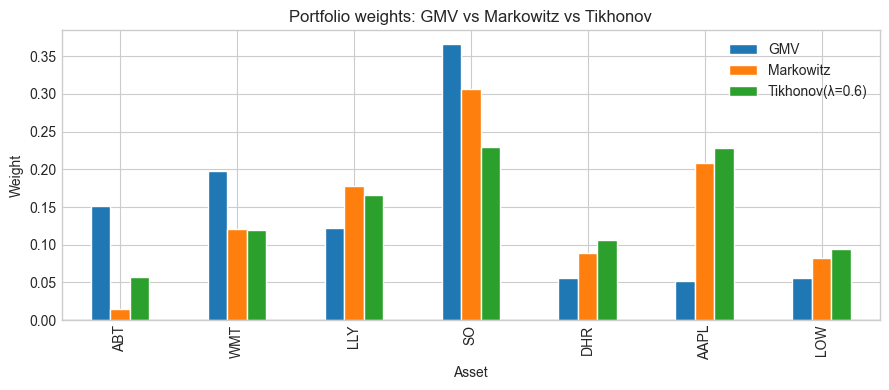

In [25]:
ax = w_all.plot(kind='bar', figsize=(9, 4))
ax.set_title('Portfolio weights: GMV vs Markowitz vs Tikhonov')
ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=0.8)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Performance comparison

By construction, the Markowitz tangency portfolio maximises the in-sample Sharpe ratio. GMV achieves the lowest variance but accepts a lower expected return. Tikhonov sits between the two: it sacrifices some Sharpe ratio relative to Markowitz in exchange for more stable, less concentrated weights.

In [26]:
perf_full = pd.concat([
    portfolio_summary(w_gmv, mu_e, Sigma),
    portfolio_summary(w_mkv, mu_e, Sigma),
    portfolio_summary(w_tik, mu_e, Sigma),
], axis=1).T
perf_full

,E[excess] (monthly),Vol (monthly),Sharpe (monthly)
GMV,0.010834,0.034258,0.316238
Markowitz,0.014545,0.039694,0.366421
Tikhonov(λ=0.6),0.015112,0.041619,0.363115


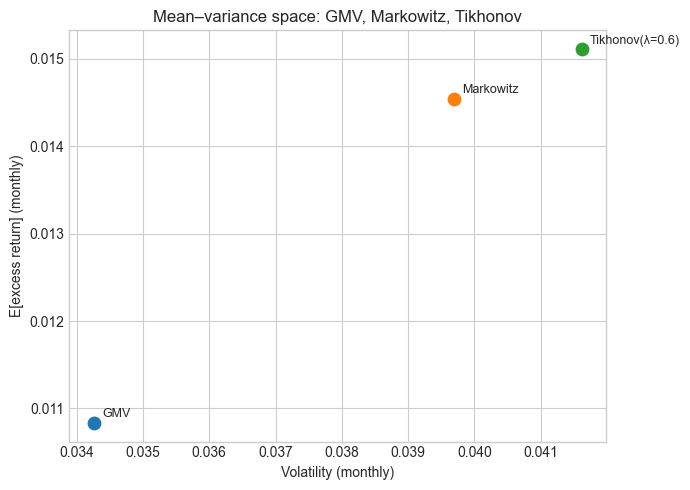

In [27]:
# Plot all three portfolios in (sigma, E[excess return]) space.
fig, ax = plt.subplots(figsize=(7, 5))

for name, row in perf_full.iterrows():
    ax.scatter(row['Vol (monthly)'], row['E[excess] (monthly)'], s=80, zorder=5)
    ax.annotate(name, xy=(row['Vol (monthly)'], row['E[excess] (monthly)']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Volatility (monthly)')
ax.set_ylabel('E[excess return] (monthly)')
ax.set_title('Mean–variance space: GMV, Markowitz, Tikhonov')
plt.tight_layout()
plt.show()